### Student Information
Name: 張家榕

Student ID: 110020036

GitHub ID: chiajungchang2003

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [1]:
!pip install wordcloud

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Shape: (847, 16)
Columns: Index(['type', 'datetime', 'post_id', 'subreddit', 'title', 'author', 'url',
       'upvotes', 'downvotes', 'upvote_ratio', 'text', 'subjectivity',
       'polarity', 'sentiment', 'entities', 'label'],
      dtype='object')
Dataset after dropping duplicates: 824
sentiment_name
positive    316
neutral     312
negative    196
Name: count, dtype: int64


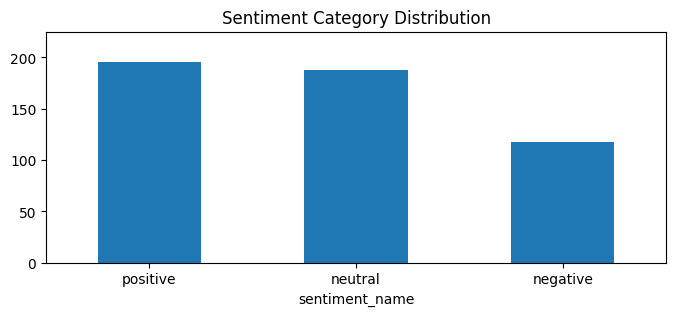

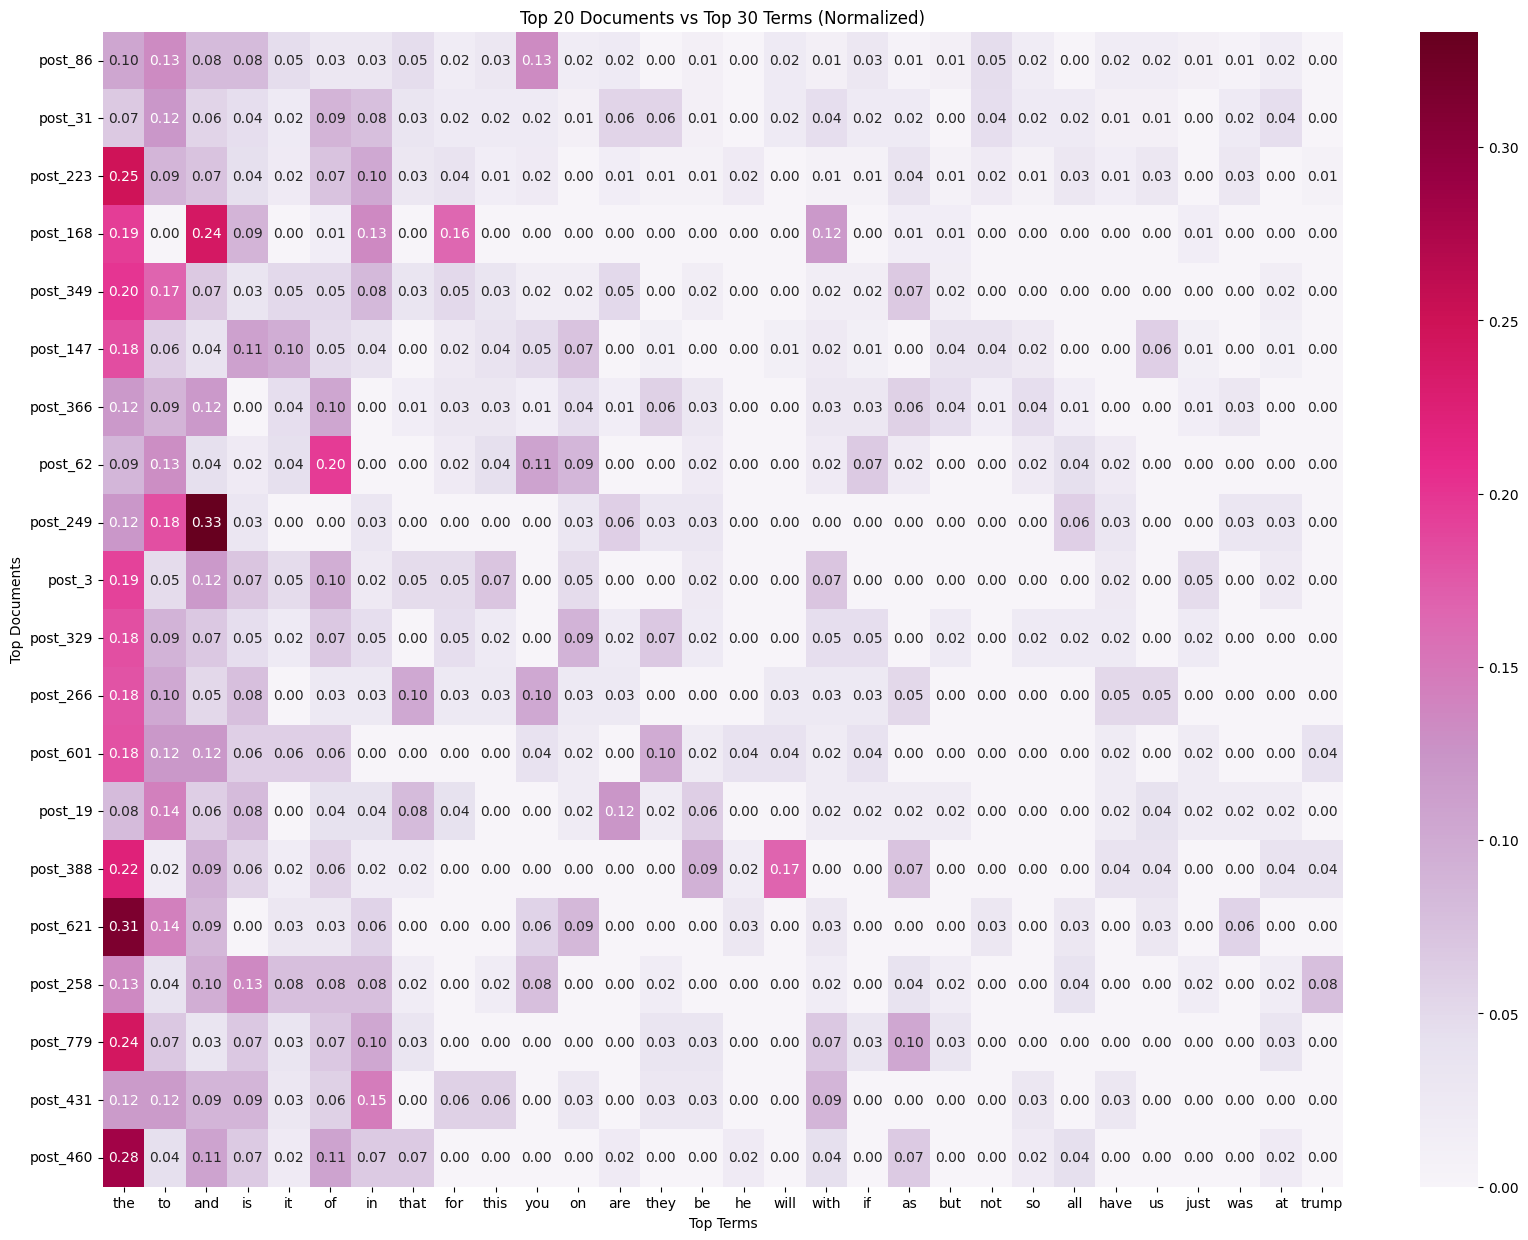

In [2]:
# --- Environment setup ---
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt')
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

# --- Helper functions ---
def simplify(df, columns):
    return df[columns].copy()

def add_mapping(df, mapping, target_column, source_column):
    df[target_column] = df[source_column].map(mapping)

# --- Load and prepare data ---
new_df = pd.read_csv('newdataset/Reddit-stock-sentiment.csv')
print(f"Shape: {new_df.shape}")
print(f"Columns: {new_df.columns}")

# Keep necessary columns
select_columns = ["text", "title", "sentiment", "subreddit", "label"]
X = simplify(new_df, select_columns)

# Map sentiment labels to readable names
mapping = {1.0: 'positive', 0.0: 'neutral', -1.0: 'negative'}
add_mapping(X, mapping, "sentiment_name", "sentiment")

# Drop duplicates
X.drop_duplicates(keep='first', inplace=True)
print(f"Dataset after dropping duplicates: {len(X)}")

# --- Quick EDA ---
print(X['sentiment_name'].value_counts())

# Optional: sample 500 posts for visualization
X_sample = X.sample(n=500, random_state=42)
X_sample.sentiment_name.value_counts().plot(
    kind='bar', title='Sentiment Category Distribution',
    ylim=[0, X_sample.sentiment_name.value_counts().max() + 30],
    rot=0, figsize=(8,3)
)
plt.show()

# --- Feature extraction ---
count_vect = CountVectorizer()
X_counts = count_vect.fit_transform(X.text)  # sparse matrix
terms = np.array(count_vect.get_feature_names_out())

# --- Top documents vs top terms heatmap ---
# Top 30 terms
term_frequencies = np.array(X_counts.sum(axis=0)).flatten()
top_terms_idx = np.argsort(term_frequencies)[-30:][::-1]

# Top 20 word-rich documents
post_word_counts = np.array(X_counts.sum(axis=1)).flatten()
top_posts_idx = np.argsort(post_word_counts)[-20:][::-1]

# Extract submatrix and normalize rows
submatrix = X_counts[top_posts_idx, :][:, top_terms_idx].toarray()
submatrix_norm = submatrix / submatrix.sum(axis=1, keepdims=True)

df_sub_norm = pd.DataFrame(
    submatrix_norm,
    index=[f"post_{i}" for i in top_posts_idx],
    columns=terms[top_terms_idx]
)

plt.figure(figsize=(20, 15))
sns.heatmap(df_sub_norm, cmap="PuRd", annot=True, fmt=".2f")
plt.title("Top 20 Documents vs Top 30 Terms (Normalized)")
plt.xlabel("Top Terms")
plt.ylabel("Top Documents")
plt.show()

# --- Sentiment-based word frequency analysis ---
# Convert boolean masks to integer indices
positive_indices = np.where(X['sentiment_name'] == 'positive')[0]
negative_indices = np.where(X['sentiment_name'] == 'negative')[0]

# Sum word counts
positive_word_freq = np.array(X_counts[positive_indices, :].sum(axis=0)).flatten()
negative_word_freq = np.array(X_counts[negative_indices, :].sum(axis=0)).flatten()

# Build DataFrames
df_positive = pd.DataFrame({"Term": terms, "Frequency": positive_word_freq})
df_negative = pd.DataFrame({"Term": terms, "Frequency": negative_word_freq})

# Log scale
df_positive["Frequency_log"] = np.log1p(df_positive["Frequency"])
df_negative["Frequency_log"] = np.log1p(df_negative["Frequency"])

# Top 100 words
df_positive_top = df_positive.sort_values(by="Frequency_log", ascending=False).head(100)
df_negative_top = df_negative.sort_values(by="Frequency_log", ascending=False).head(100)

# --- Plotly bar charts ---
fig_pos = px.bar(df_positive_top, x="Term", y="Frequency_log",
                 title="Top 100 Frequent Words (Positive Context, Log Scale)",
                 labels={"Frequency_log": "Log(Count + 1)"})
fig_pos.update_layout(xaxis_tickangle=-45, height=600, width=1200)
fig_pos.show()

fig_neg = px.bar(df_negative_top, x="Term", y="Frequency_log",
                 title="Top 100 Frequent Words (Negative Context, Log Scale)",
                 labels={"Frequency_log": "Log(Count + 1)"})
fig_neg.update_layout(xaxis_tickangle=-45, height=600, width=1200)
fig_neg.show()


# Phase 2

### 5.4.2 Finding Frequent pattern

In [8]:
### Begin Assignment Here
#Create separate DataFrames for each category
categories = X['sentiment_name'].unique()  # Get unique category labels
category_dfs = {}  # Dictionary to store DataFrames for each category

for category in categories:
    # Filter the original DataFrame by category
    category_dfs[category] = X[X['sentiment_name'] == category].copy()

# Function to create term-document frequency DataFrame for each category
def create_term_document_df(df):
    count_vect = CountVectorizer()  # Initialize the CountVectorizer
    X_counts = count_vect.fit_transform(df['text'])  # Transform the text data into word counts
    
    # Get the unique words (vocabulary) from the vectorizer
    words = count_vect.get_feature_names_out()
    
    # Create a DataFrame where rows are documents and columns are words
    term_document_df = pd.DataFrame(X_counts.toarray(), columns=words)
    
    return term_document_df

# Create term-document frequency DataFrames for each category
filt_term_document_dfs = {}  # Dictionary to store term-document DataFrames for each category

for category in categories:
    filt_term_document_dfs[category] = create_term_document_df(category_dfs[category])

In [11]:
category_number=2 #You can change it from 0 to 2
print(f"Filtered Term-Document Frequency DataFrame for Category {categories[category_number]}:")
filt_term_document_dfs[categories[category_number]]

Filtered Term-Document Frequency DataFrame for Category neutral:


,00,000,02,03,10,100,10yr,11,12,1242,...,year,years,yes,yesterday,yet,yields,yo,you,your,yup
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
308,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
309,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
310,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


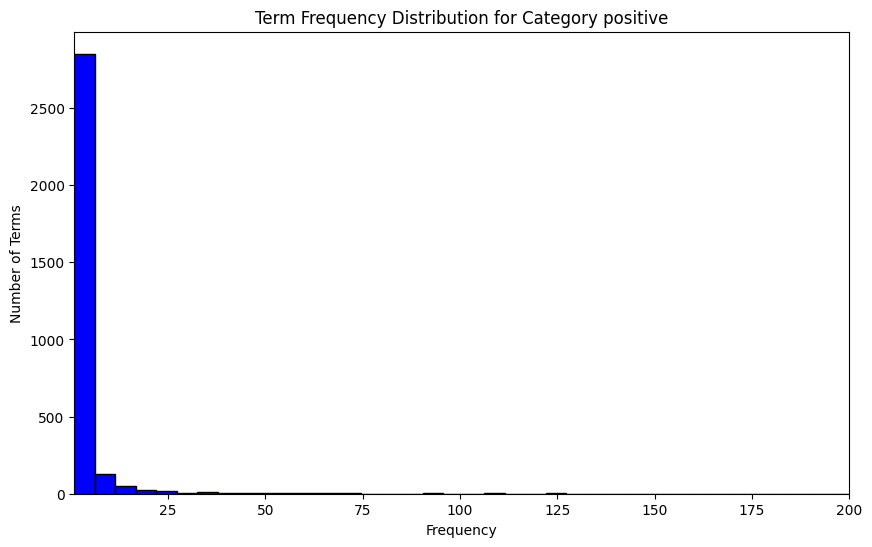

In [15]:
# Sum over all documents to get total frequency for each word
category_number=1 #You can change it from 0 to 2
word_counts = filt_term_document_dfs[categories[category_number]].sum(axis=0).to_numpy()
 
# Visualize the frequency distribution
plt.figure(figsize=(10, 6))
plt.hist(word_counts, bins=100, color='blue', edgecolor='black')
plt.title(f'Term Frequency Distribution for Category {categories[category_number]}')
plt.xlabel('Frequency')
plt.ylabel('Number of Terms')
plt.xlim(1, 200)
plt.show()

**Filter the the top 5% adn bottom 1% word based on their sum across all docs**

In [16]:
# Filter the bottom 1% and top 5% words based on their sum across all documents
def filter_top_bottom_words_by_sum(term_document_df, top_percent=0.05, bottom_percent=0.01):
    # Calculate the sum of each word across all documents
    word_sums = term_document_df.sum(axis=0)
    
    # Sort the words by their total sum
    sorted_words = word_sums.sort_values()
    
    # Calculate the number of words to remove
    total_words = len(sorted_words)
    top_n = int(top_percent * total_words)
    bottom_n = int(bottom_percent * total_words)
    
    # Get the words to remove from the top 5% and bottom 1%
    words_to_remove = pd.concat([sorted_words.head(bottom_n), sorted_words.tail(top_n)]).index
    print(f'Bottom {bottom_percent*100}% words: \n{sorted_words.head(bottom_n)}') #Here we print which words correspond to the bottom percentage we filter
    print(f'Top {top_percent*100}% words: \n{sorted_words.tail(top_n)}') #Here we print which words correspond to the top percentage we filter
    # Return the DataFrame without the filtered words
    return term_document_df.drop(columns=words_to_remove)

# Apply the filtering function to each category
term_document_dfs = {}

for category in categories:
    print(f'\nFor category {category} we filter the following words:')
    term_document_dfs[category] = filter_top_bottom_words_by_sum(filt_term_document_dfs[category])



For category negative we filter the following words:
Bottom 1.0% words: 
ws                 1
wsb                1
xeqt               1
1700               1
ya                 1
2011               1
2s                 1
11                 1
125                1
13                 1
140                1
portfolios         1
poses              1
permitted          1
pharmaceuticals    1
philosophy         1
dtype: int64
Top 5.0% words: 
too          9
make         9
some         9
want         9
economy      9
          ... 
it          99
is         113
and        121
to         144
the        235
Length: 81, dtype: int64

For category positive we filter the following words:
Bottom 1.0% words: 
208             1
wrote           1
1947            1
1945            1
186             1
17th            1
1728            1
160             1
15m             1
150             1
yoyo            1
reservations    1
researches      1
research        1
requires        1
mistakes        1
08      

**Convert dataframe to transactional database**

In [17]:
from PAMI.extras.convert.DF2DB import DF2DB            

# Loop through the dictionary of term-document DataFrames
for category in term_document_dfs:
    # Replace dots with underscores in the category name to avoid errors in the file creation
    category_safe = category.replace('.', '_')
    
    # Create the DenseFormatDF object and convert to a transactional database
    obj = DF2DB(term_document_dfs[category])           
        
    obj.convert2TransactionalDatabase(f'td_freq_db_{category_safe}.csv', '>=', 1)


**Check the conversion**

Database size (total no of transactions) : 195
Number of items : 1534
Minimum Transaction Size : 1
Average Transaction Size : 12.95897435897436
Maximum Transaction Size : 66
Standard Deviation Transaction Size : 10.829132549219873
Variance in Transaction Sizes : 117.87459688078245
Sparsity : 0.9915521679537325


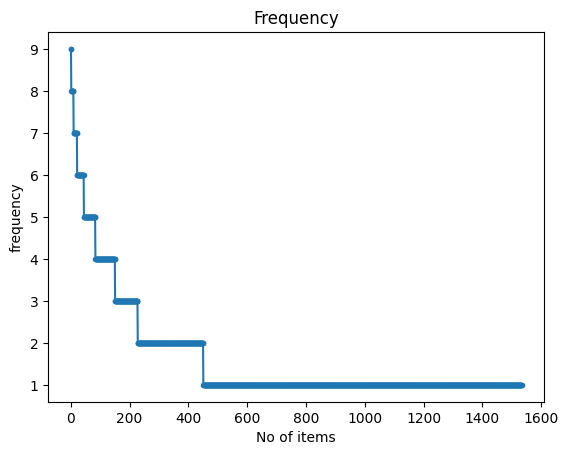

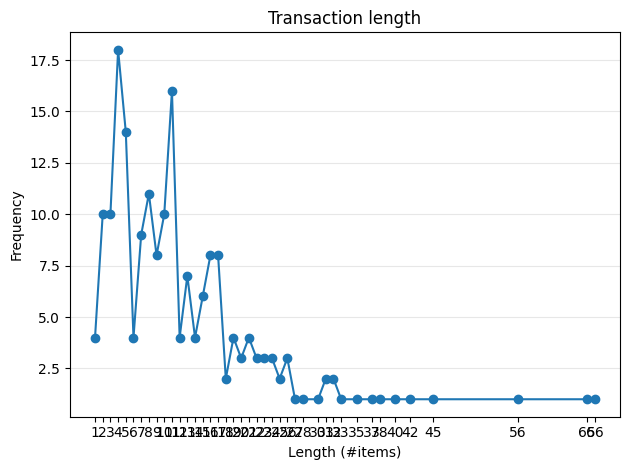

In [19]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_db_negative.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 307
Number of items : 1192
Minimum Transaction Size : 1
Average Transaction Size : 5.93485342019544
Maximum Transaction Size : 32
Standard Deviation Transaction Size : 4.840349231082412
Variance in Transaction Sizes : 23.505545975176172
Sparsity : 0.9950210961239971


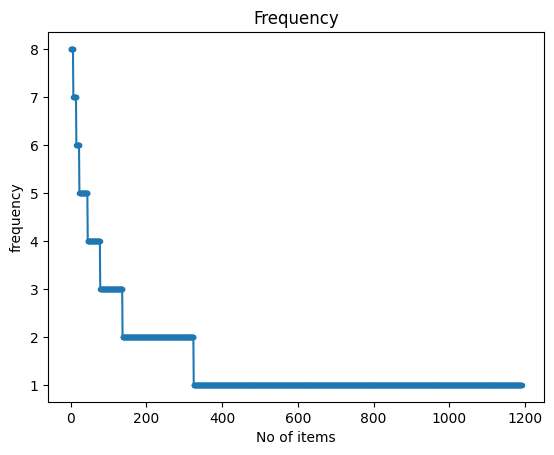

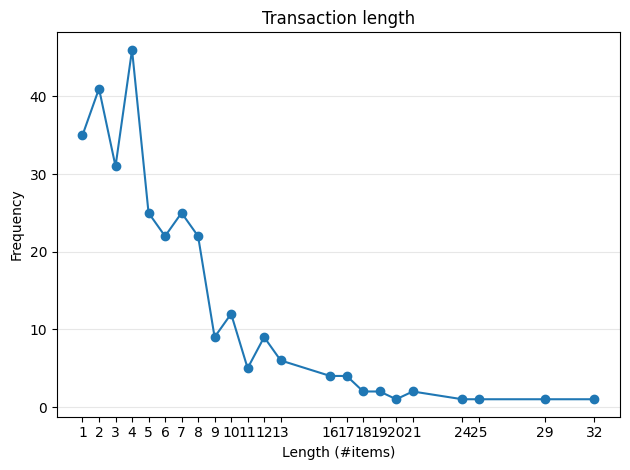

In [20]:
obj = tds.TransactionalDatabase('td_freq_db_neutral.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 314
Number of items : 2940
Minimum Transaction Size : 1
Average Transaction Size : 16.43949044585987
Maximum Transaction Size : 196
Standard Deviation Transaction Size : 22.215315076410153
Variance in Transaction Sizes : 495.09696587371036
Sparsity : 0.9944083365830408


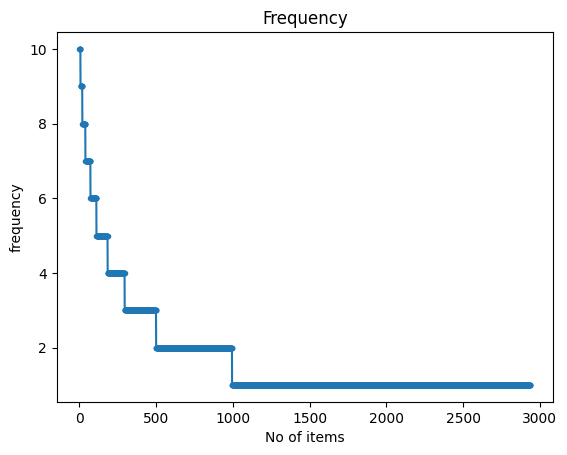

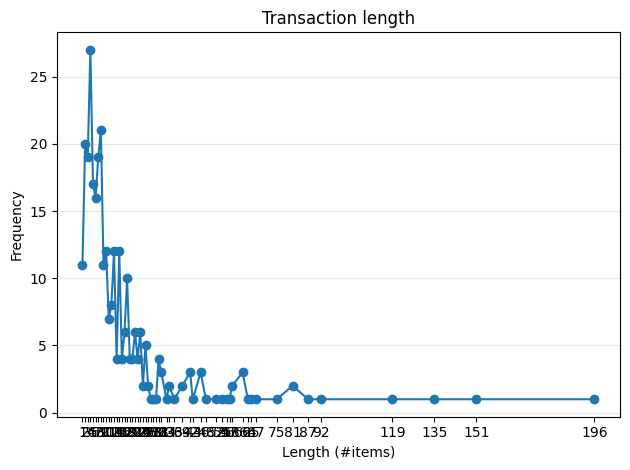

In [21]:
obj = tds.TransactionalDatabase('td_freq_db_positive.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

**Mine patterns using FPGrowth Algorithm**

In [25]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=6
obj1 = alg.FPGrowth(iFile='td_freq_db_negative.csv', minSup=minSup)
obj1.mine()
frequentPatternsDF_negative= obj1.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_negative))) #print the total number of patterns
print('Runtime: ' + str(obj1.getRuntime())) #measure the runtime

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 45
Runtime: 0.007241010665893555


In [26]:
obj1.save('freq_patterns_negative_minSup6.txt') #save the patterns
frequentPatternsDF_negative

,Patterns,Support
0,retard,6
1,investment,6
2,seems,6
3,without,6
4,life,6
5,man,6
6,does,6
7,idiot,6
8,least,6
9,over,6


In [27]:
obj2 = alg.FPGrowth(iFile='td_freq_db_neutral.csv', minSup=minSup)
obj2.mine()
frequentPatternsDF_neutral= obj2.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_neutral))) #print the total number of patterns
print('Runtime: ' + str(obj2.getRuntime())) #measure the runtime

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 23
Runtime: 0.005420207977294922


In [28]:
obj2.save('freq_patterns_neutral_minSup6.txt') #save the patterns
frequentPatternsDF_neutral

,Patterns,Support
0,call,6
1,news,6
2,re,6
3,anything,6
4,already,6
5,stocks,6
6,out,6
7,here,6
8,want,7
9,by,7


In [29]:
obj3 = alg.FPGrowth(iFile='td_freq_db_positive.csv', minSup=minSup)
obj3.mine()
frequentPatternsDF_positive= obj3.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_positive))) #print the total number of patterns
print('Runtime: ' + str(obj3.getRuntime())) #measure the runtime

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 111
Runtime: 0.014175891876220703


In [30]:
obj3.save('freq_patterns_positive_minSup6.txt') #save the patterns
frequentPatternsDF_positive

,Patterns,Support
0,ever,6
1,months,6
2,end,6
3,actually,6
4,target,6
...,...,...
106,someone,10
107,where,10
108,america,10
109,thanks,10
